**Justification — Scaled + SMOTE-Tomek for KNN (Fire Prediction)**

* **KNN is distance-based** → scaling is mandatory to prevent variables with large ranges (e.g., temperature, wind) from dominating the distance.
* **Fire events are rare** → SMOTE balances the dataset so fire samples have enough neighbors to be correctly identified.
* **Synthetic oversampling alone is noisy** → Tomek links remove overlapping and ambiguous samples near class boundaries.
* **Cleaner decision boundary** → SMOTE + Tomek improves neighborhood quality, which is critical for KNN.
* **Better minority detection** → improves recall and F1-score for fire cases without sacrificing overall stability.
* **More robust generalization** → reduced bias toward the non-fire class and less sensitivity to outliers.

**Conclusion:**
Scaled **SMOTE + Tomek** data is the most reliable configuration for KNN in an imbalanced fire-prediction problem.


## **Imports**

In [96]:
import pandas as pd
import pickle
from pathlib import Path
import numpy as np
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, 
    precision_score, 
    recall_score, 
    f1_score,
    classification_report, 
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    matthews_corrcoef,
    make_scorer
)
from sklearn.model_selection import cross_val_score
from skopt import BayesSearchCV
from skopt.space import Integer, Categorical
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

## **Loading data**

- Code\Merged_Data_Preprocessing\Normalized_Data_split\X_train_smote_tomek.parquet
- Code\Merged_Data_Preprocessing\Resampled_Data_split\smote_tomek\y_smote_tomek.pkl

- Code\Merged_Data_Preprocessing\Resampled_Data_split\test\X_test.parquet
- Code\Merged_Data_Preprocessing\Resampled_Data_split\test\y_test.pkl

- Code\Merged_Data_Preprocessing\Resampled_Data_split\val\X_val.parquet
- Code\Merged_Data_Preprocessing\Resampled_Data_split\val\y_val.pkl

In [97]:
# Define base path
base_path = Path('../../../../Merged_Data_Preprocessing')


In [98]:
# Load training data (SMOTE-Tomek)
X_train = pd.read_parquet(base_path /'Normalized_Data_split/X_train_smote_tomek.parquet')
with open(base_path /'Resampled_Data_split/smote_tomek/y_smote_tomek.pkl', 'rb') as f:
    y_train = pickle.load(f)

In [99]:
# Load test data
X_test = pd.read_parquet(base_path / 'Resampled_Data_split/test/X_test.parquet')
with open(base_path / 'Resampled_Data_split/test/y_test.pkl', 'rb') as f:
    y_test = pickle.load(f)


In [100]:
# Load validation data
X_val = pd.read_parquet(base_path / 'Resampled_Data_split/val/X_val.parquet')
with open(base_path / 'Resampled_Data_split/val/y_val.pkl', 'rb') as f:
    y_val = pickle.load(f)


In [101]:
# Display shapes
print("Training set:")
print(f"  X_train: {X_train.shape}")
print(f"  y_train: {y_train.shape if hasattr(y_train, 'shape') else len(y_train)}")
print("\nTest set:")
print(f"  X_test: {X_test.shape}")
print(f"  y_test: {y_test.shape if hasattr(y_test, 'shape') else len(y_test)}")
print("\nValidation set:")
print(f"  X_val: {X_val.shape}")
print(f"  y_val: {y_val.shape if hasattr(y_val, 'shape') else len(y_val)}")

Training set:
  X_train: (30266, 64)
  y_train: (30266,)

Test set:
  X_test: (3477, 64)
  y_test: (3477,)

Validation set:
  X_val: (3477, 64)
  y_val: (3477,)


## **KNN**

### **Model Training**

In [102]:
# Initialize KNN model
knn = KNeighborsClassifier(
    n_neighbors=11,
    weights='distance',
    algorithm='auto',
    metric='minkowski',
    p=1,  # Manhattan distance more robust for outliers
    n_jobs=-1
)

# Train the model
print("Training KNN model...")
knn.fit(X_train, y_train)
print("Training complete!")

Training KNN model...
Training complete!


### **Predictions**

In [103]:
# Make predictions
y_train_pred = knn.predict(X_train)
y_val_pred = knn.predict(X_val)
y_test_pred = knn.predict(X_test)

# Get probability predictions for ROC-AUC
y_train_proba = knn.predict_proba(X_train)[:, 1]
y_val_proba = knn.predict_proba(X_val)[:, 1]
y_test_proba = knn.predict_proba(X_test)[:, 1]

print("Predictions complete!")

Predictions complete!


### **Model Evaluation**

In [104]:
def evaluate_model(y_true, y_pred, y_proba, dataset_name):
    """Evaluate model performance and display metrics"""
    print(f"\n{'='*60}")
    print(f"{dataset_name} SET EVALUATION")
    print(f"{'='*60}")
    
    # Calculate confusion matrix for specificity
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    
    # Calculate metrics
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)  # Sensitivity/TPR
    specificity = tn / (tn + fp)  # TNR
    f1 = f1_score(y_true, y_pred)
    mcc = matthews_corrcoef(y_true, y_pred)
    roc_auc = roc_auc_score(y_true, y_proba)
    
    print(f"\nAccuracy:    {accuracy:.4f}")
    print(f"Precision:   {precision:.4f}")
    print(f"Recall:      {recall:.4f}")
    print(f"Specificity: {specificity:.4f}")
    print(f"F1-Score:    {f1:.4f}")
    print(f"MCC:         {mcc:.4f}")
    print(f"ROC-AUC:     {roc_auc:.4f}")
    
    print(f"\n{'-'*60}")
    print("Classification Report:")
    print(f"{'-'*60}")
    print(classification_report(y_true, y_pred, target_names=['No Fire', 'Fire']))
    
    return {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'specificity': specificity,
        'f1_score': f1,
        'mcc': mcc,
        'roc_auc': roc_auc
    }

# Evaluate on all datasets
train_metrics = evaluate_model(y_train, y_train_pred, y_train_proba, "TRAINING")
val_metrics = evaluate_model(y_val, y_val_pred, y_val_proba, "VALIDATION")
test_metrics = evaluate_model(y_test, y_test_pred, y_test_proba, "TEST")


TRAINING SET EVALUATION

Accuracy:    1.0000
Precision:   1.0000
Recall:      1.0000
Specificity: 1.0000
F1-Score:    1.0000
MCC:         1.0000
ROC-AUC:     1.0000

------------------------------------------------------------
Classification Report:
------------------------------------------------------------
              precision    recall  f1-score   support

     No Fire       1.00      1.00      1.00     15133
        Fire       1.00      1.00      1.00     15133

    accuracy                           1.00     30266
   macro avg       1.00      1.00      1.00     30266
weighted avg       1.00      1.00      1.00     30266


VALIDATION SET EVALUATION

Accuracy:    0.8873
Precision:   0.3047
Recall:      0.7413
Specificity: 0.8962
F1-Score:    0.4319
MCC:         0.4280
ROC-AUC:     0.8852

------------------------------------------------------------
Classification Report:
------------------------------------------------------------
              precision    recall  f1-score   s

### **Confusion Matrices**

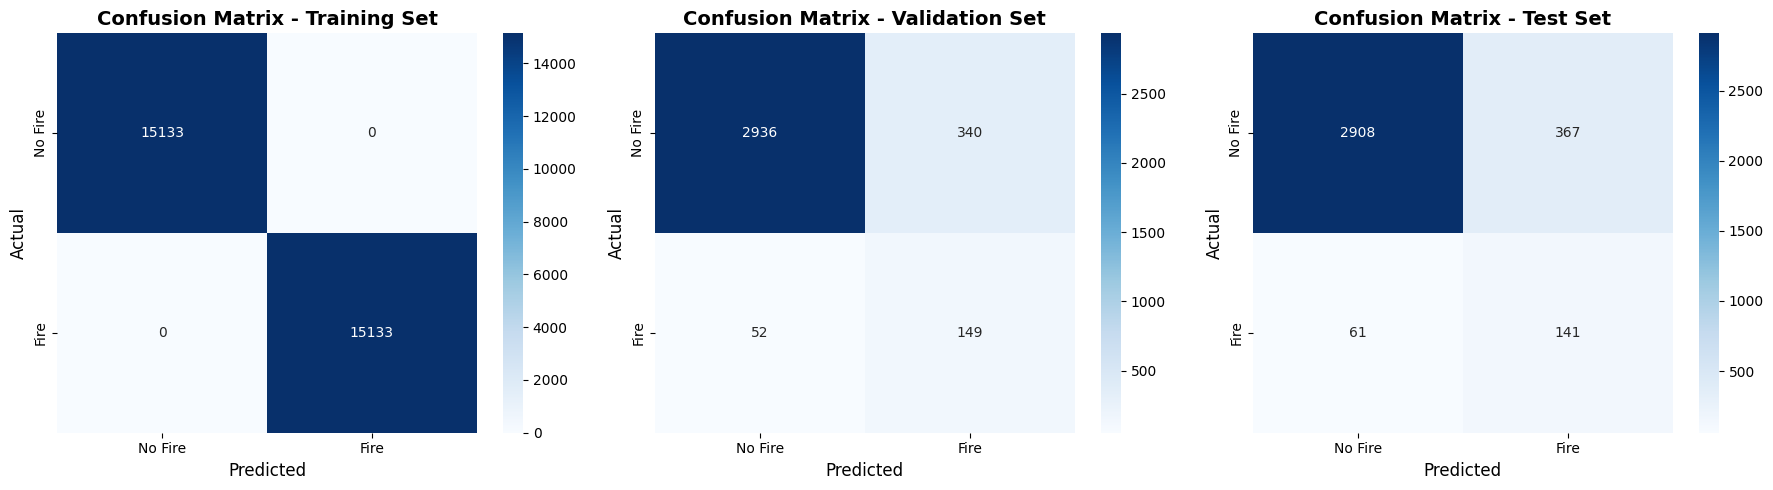

In [105]:
# Plot confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

datasets = [
    (y_train, y_train_pred, "Training Set"),
    (y_val, y_val_pred, "Validation Set"),
    (y_test, y_test_pred, "Test Set")
]

for idx, (y_true, y_pred, title) in enumerate(datasets):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                xticklabels=['No Fire', 'Fire'],
                yticklabels=['No Fire', 'Fire'])
    axes[idx].set_title(f'Confusion Matrix - {title}', fontsize=14, fontweight='bold')
    axes[idx].set_ylabel('Actual', fontsize=12)
    axes[idx].set_xlabel('Predicted', fontsize=12)

plt.tight_layout()


# Save figureplt.show()

output_dir = Path('../../../../../Rapport_TP/images/KNN')
plt.savefig(output_dir / 'confusion_matrices_KNN_predefined.png', dpi=300, bbox_inches='tight')
output_dir.mkdir(parents=True, exist_ok=True)

### **ROC Curves**

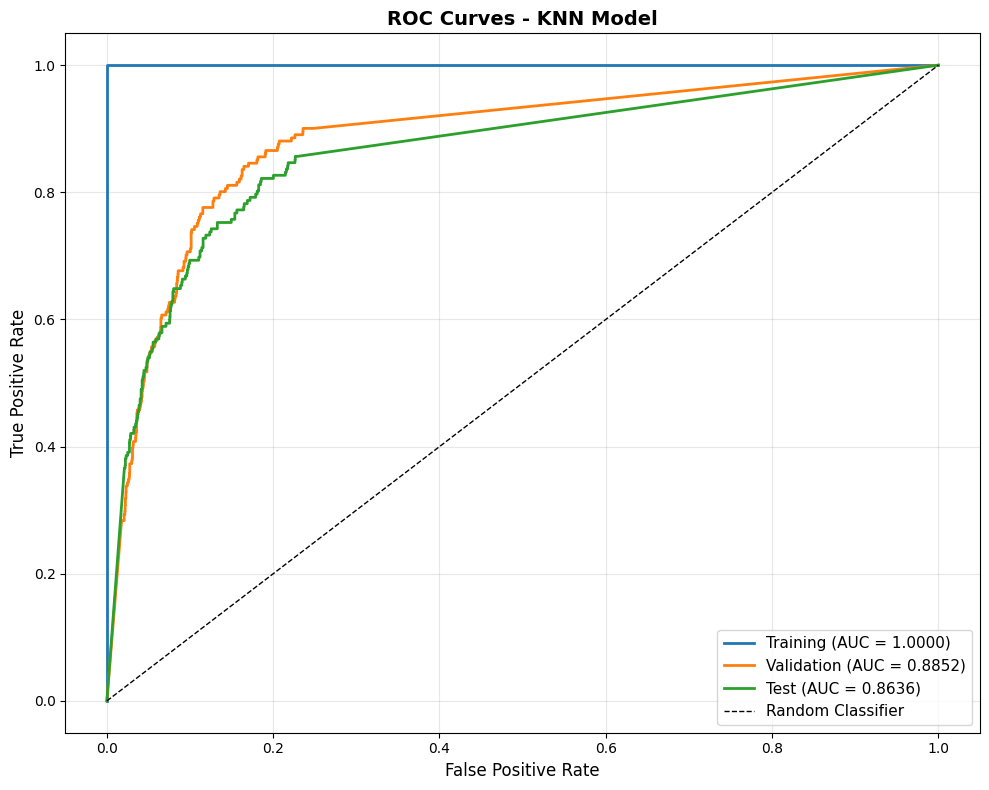

In [106]:
# Plot ROC curves
plt.figure(figsize=(10, 8))

# Training set
fpr_train, tpr_train, _ = roc_curve(y_train, y_train_proba)
plt.plot(fpr_train, tpr_train, label=f'Training (AUC = {train_metrics["roc_auc"]:.4f})', linewidth=2)

# Validation set
fpr_val, tpr_val, _ = roc_curve(y_val, y_val_proba)
plt.plot(fpr_val, tpr_val, label=f'Validation (AUC = {val_metrics["roc_auc"]:.4f})', linewidth=2)

# Test set
fpr_test, tpr_test, _ = roc_curve(y_test, y_test_proba)
plt.plot(fpr_test, tpr_test, label=f'Test (AUC = {test_metrics["roc_auc"]:.4f})', linewidth=2)

# Diagonal line
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier', linewidth=1)

plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves - KNN Model', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()


# Save figureplt.show()

output_dir = Path('../../../../../Rapport_TP/images/KNN')
plt.savefig(output_dir / 'roc_curves_KNN_predefined.png', dpi=300, bbox_inches='tight')
output_dir.mkdir(parents=True, exist_ok=True)

### **Metrics Comparison**


METRICS COMPARISON ACROSS DATASETS
             Training  Validation    Test
accuracy          1.0      0.8873  0.8769
precision         1.0      0.3047  0.2776
recall            1.0      0.7413  0.6980
specificity       1.0      0.8962  0.8879
f1_score          1.0      0.4319  0.3972
mcc               1.0      0.4280  0.3881
roc_auc           1.0      0.8852  0.8636


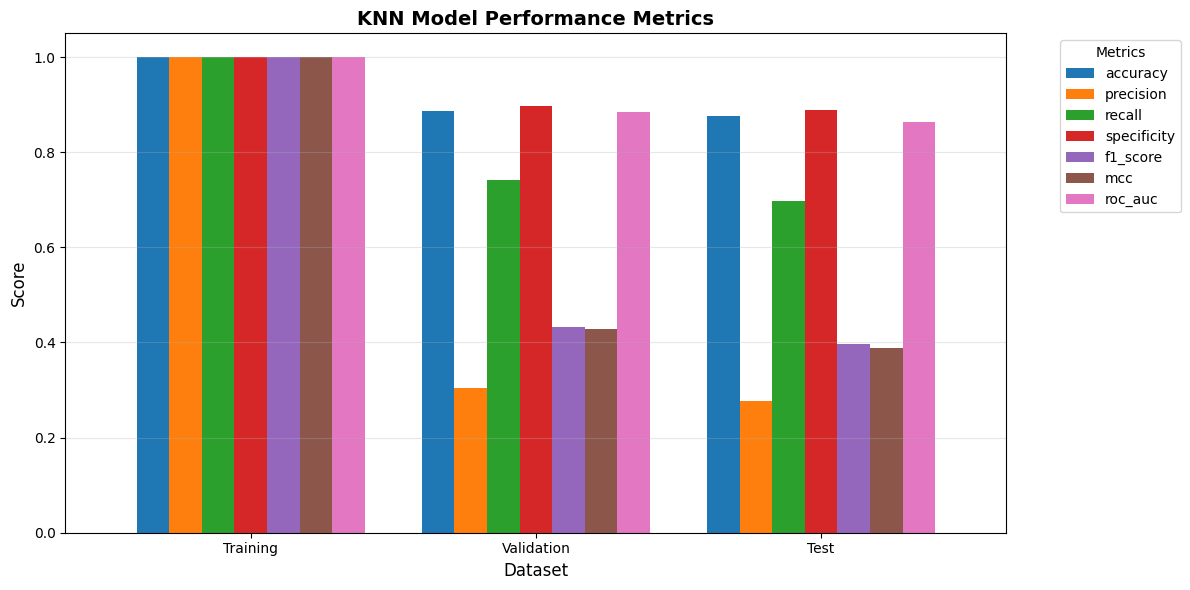

In [107]:
# Compare metrics across datasets
metrics_df = pd.DataFrame({
    'Training': train_metrics,
    'Validation': val_metrics,
    'Test': test_metrics
})

print("\n" + "="*70)
print("METRICS COMPARISON ACROSS DATASETS")
print("="*70)
print(metrics_df.round(4))
print("="*70)

# Visualize metrics comparison
fig, ax = plt.subplots(figsize=(12, 6))
metrics_df.T.plot(kind='bar', ax=ax, width=0.8)
ax.set_title('KNN Model Performance Metrics', fontsize=14, fontweight='bold')
ax.set_xlabel('Dataset', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_ylim([0, 1.05])
ax.legend(title='Metrics', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(True, alpha=0.3, axis='y')
plt.xticks(rotation=0)
plt.tight_layout()


# Save figureplt.show()

output_dir = Path('../../../../../Rapport_TP/images/KNN')
plt.savefig(output_dir / 'metrics_comparison_KNN_predefined.png', dpi=300, bbox_inches='tight')
output_dir.mkdir(parents=True, exist_ok=True)

## **Bayesian Search**

### **Define Search Space**

In [108]:
# Define hyperparameter search space for KNN
search_space = {
    'n_neighbors': Integer(3, 31),  # Number of neighbors
    'weights': Categorical(['uniform', 'distance']),  # Weight function
    'metric': Categorical(['euclidean', 'manhattan', 'minkowski']),  # Distance metric
    'p': Integer(1, 2),  # Power parameter for minkowski (1=manhattan, 2=euclidean)
    'algorithm': Categorical(['auto', 'ball_tree', 'kd_tree', 'brute'])  # Algorithm for computing neighbors
}

print("Search space defined:")
for param, space in search_space.items():
    print(f"  {param}: {space}")

Search space defined:
  n_neighbors: Integer(low=3, high=31, prior='uniform', transform='identity')
  weights: Categorical(categories=('uniform', 'distance'), prior=None)
  metric: Categorical(categories=('euclidean', 'manhattan', 'minkowski'), prior=None)
  p: Integer(low=1, high=2, prior='uniform', transform='identity')
  algorithm: Categorical(categories=('auto', 'ball_tree', 'kd_tree', 'brute'), prior=None)


### **Configure BayesSearchCV**

In [109]:
# Initialize base KNN model
knn_base = KNeighborsClassifier(n_jobs=-1)

# Configure Bayesian Search with F1-score as the optimization metric
bayes_search = BayesSearchCV(
    estimator=knn_base,
    search_spaces=search_space,
    n_iter=50,  # Number of parameter settings sampled
    cv=5,  # 5-fold cross-validation
    scoring='f1',  # Optimize for F1-score (balance precision/recall for imbalanced data)
    n_jobs=-1,  # Use all CPU cores
    verbose=1,
    random_state=42,
    return_train_score=True
)

print("BayesSearchCV configured:")
print(f"  Estimator: KNeighborsClassifier")
print(f"  Iterations: 50")
print(f"  Cross-validation folds: 5")
print(f"  Scoring metric: F1-score")
print(f"  Random state: 42")

BayesSearchCV configured:
  Estimator: KNeighborsClassifier
  Iterations: 50
  Cross-validation folds: 5
  Scoring metric: F1-score
  Random state: 42


### **Run Bayesian Optimization**

In [110]:
# Fit Bayesian Search on training data
print("Starting Bayesian hyperparameter optimization...")
print("This may take several minutes...\n")

bayes_search.fit(X_train, y_train)

print("\n" + "="*70)
print("BAYESIAN OPTIMIZATION COMPLETED")
print("="*70)

Starting Bayesian hyperparameter optimization...
This may take several minutes...

Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 ca

### **Best Parameters & Score**

In [111]:
# Display best parameters and cross-validation score
print("Best Parameters Found:")
print("-" * 70)
for param, value in bayes_search.best_params_.items():
    print(f"  {param:15s}: {value}")

print("\n" + "="*70)
print(f"Best Cross-Validation F1-Score: {bayes_search.best_score_:.4f}")
print("="*70)

# Get the best estimator
best_knn = bayes_search.best_estimator_
print("\nBest KNN model retrieved and ready for evaluation.")

Best Parameters Found:
----------------------------------------------------------------------
  algorithm      : kd_tree
  metric         : manhattan
  n_neighbors    : 4
  p              : 1
  weights        : distance

Best Cross-Validation F1-Score: 0.9614

Best KNN model retrieved and ready for evaluation.


### **Optimization History**

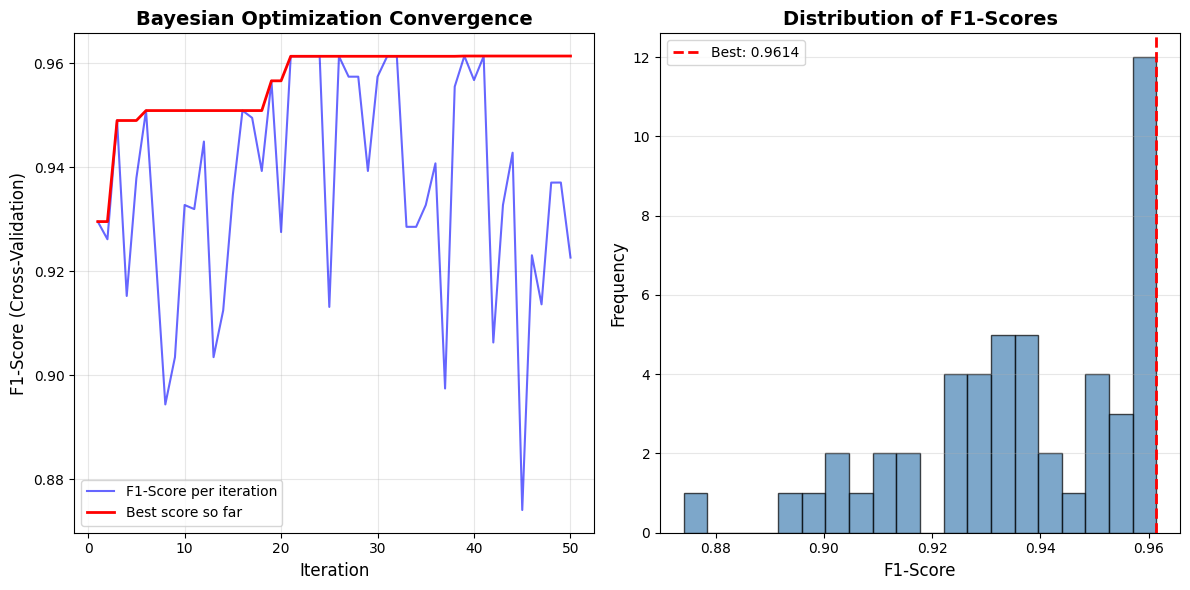

<Figure size 640x480 with 0 Axes>

In [112]:
# Extract and visualize optimization history
results_df = pd.DataFrame(bayes_search.cv_results_)

# Plot convergence: F1-score improvement over iterations
plt.figure(figsize=(12, 6))

# Get mean test scores
mean_scores = results_df['mean_test_score'].values
iterations = range(1, len(mean_scores) + 1)

plt.subplot(1, 2, 1)
plt.plot(iterations, mean_scores, 'b-', alpha=0.6, label='F1-Score per iteration')
plt.plot(iterations, np.maximum.accumulate(mean_scores), 'r-', linewidth=2, label='Best score so far')
plt.xlabel('Iteration', fontsize=12)
plt.ylabel('F1-Score (Cross-Validation)', fontsize=12)
plt.title('Bayesian Optimization Convergence', fontsize=14, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)

# Plot distribution of scores
plt.subplot(1, 2, 2)
plt.hist(mean_scores, bins=20, color='steelblue', edgecolor='black', alpha=0.7)
plt.axvline(bayes_search.best_score_, color='red', linestyle='--', linewidth=2, label=f'Best: {bayes_search.best_score_:.4f}')
plt.xlabel('F1-Score', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Distribution of F1-Scores', fontsize=14, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Save figure
output_dir = Path('../../../../../Rapport_TP/images/KNN')
output_dir.mkdir(parents=True, exist_ok=True)
plt.savefig(output_dir / 'bayesian_optimization_history_KNN.png', dpi=300, bbox_inches='tight')

### **Optimized Model Predictions**

In [113]:
# Make predictions with optimized model
y_train_pred_opt = best_knn.predict(X_train)
y_val_pred_opt = best_knn.predict(X_val)
y_test_pred_opt = best_knn.predict(X_test)

# Get probability predictions
y_train_proba_opt = best_knn.predict_proba(X_train)[:, 1]
y_val_proba_opt = best_knn.predict_proba(X_val)[:, 1]
y_test_proba_opt = best_knn.predict_proba(X_test)[:, 1]

print("Predictions with optimized KNN model complete!")

Predictions with optimized KNN model complete!


### **Optimized Model Evaluation**

In [114]:
# Evaluate optimized model on all datasets
train_metrics_opt = evaluate_model(y_train, y_train_pred_opt, y_train_proba_opt, "TRAINING (OPTIMIZED)")
val_metrics_opt = evaluate_model(y_val, y_val_pred_opt, y_val_proba_opt, "VALIDATION (OPTIMIZED)")
test_metrics_opt = evaluate_model(y_test, y_test_pred_opt, y_test_proba_opt, "TEST (OPTIMIZED)")


TRAINING (OPTIMIZED) SET EVALUATION

Accuracy:    1.0000
Precision:   1.0000
Recall:      1.0000
Specificity: 1.0000
F1-Score:    1.0000
MCC:         1.0000
ROC-AUC:     1.0000

------------------------------------------------------------
Classification Report:
------------------------------------------------------------
              precision    recall  f1-score   support

     No Fire       1.00      1.00      1.00     15133
        Fire       1.00      1.00      1.00     15133

    accuracy                           1.00     30266
   macro avg       1.00      1.00      1.00     30266
weighted avg       1.00      1.00      1.00     30266


VALIDATION (OPTIMIZED) SET EVALUATION

Accuracy:    0.9123
Precision:   0.3514
Recall:      0.6119
Specificity: 0.9307
F1-Score:    0.4465
MCC:         0.4209
ROC-AUC:     0.8441

------------------------------------------------------------
Classification Report:
------------------------------------------------------------
              precision

### **Comparison: Predefined vs Optimized**

In [115]:
# Compare predefined vs optimized models
comparison_df = pd.DataFrame({
    'Predefined (Train)': train_metrics,
    'Optimized (Train)': train_metrics_opt,
    'Predefined (Val)': val_metrics,
    'Optimized (Val)': val_metrics_opt,
    'Predefined (Test)': test_metrics,
    'Optimized (Test)': test_metrics_opt
})

print("\n" + "="*90)
print("COMPARISON: PREDEFINED vs OPTIMIZED KNN MODEL")
print("="*90)
print(comparison_df.round(4))
print("="*90)

# Calculate improvements
print("\n" + "="*90)
print("IMPROVEMENTS ON TEST SET")
print("="*90)
for metric in test_metrics.keys():
    improvement = (test_metrics_opt[metric] - test_metrics[metric]) * 100
    print(f"{metric:15s}: {improvement:+.2f}%")
print("="*90)


COMPARISON: PREDEFINED vs OPTIMIZED KNN MODEL
             Predefined (Train)  Optimized (Train)  Predefined (Val)  \
accuracy                    1.0                1.0            0.8873   
precision                   1.0                1.0            0.3047   
recall                      1.0                1.0            0.7413   
specificity                 1.0                1.0            0.8962   
f1_score                    1.0                1.0            0.4319   
mcc                         1.0                1.0            0.4280   
roc_auc                     1.0                1.0            0.8852   

             Optimized (Val)  Predefined (Test)  Optimized (Test)  
accuracy              0.9123             0.8769            0.9019  
precision             0.3514             0.2776            0.3156  
recall                0.6119             0.6980            0.5891  
specificity           0.9307             0.8879            0.9212  
f1_score              0.4465        

### **Visual Comparison**

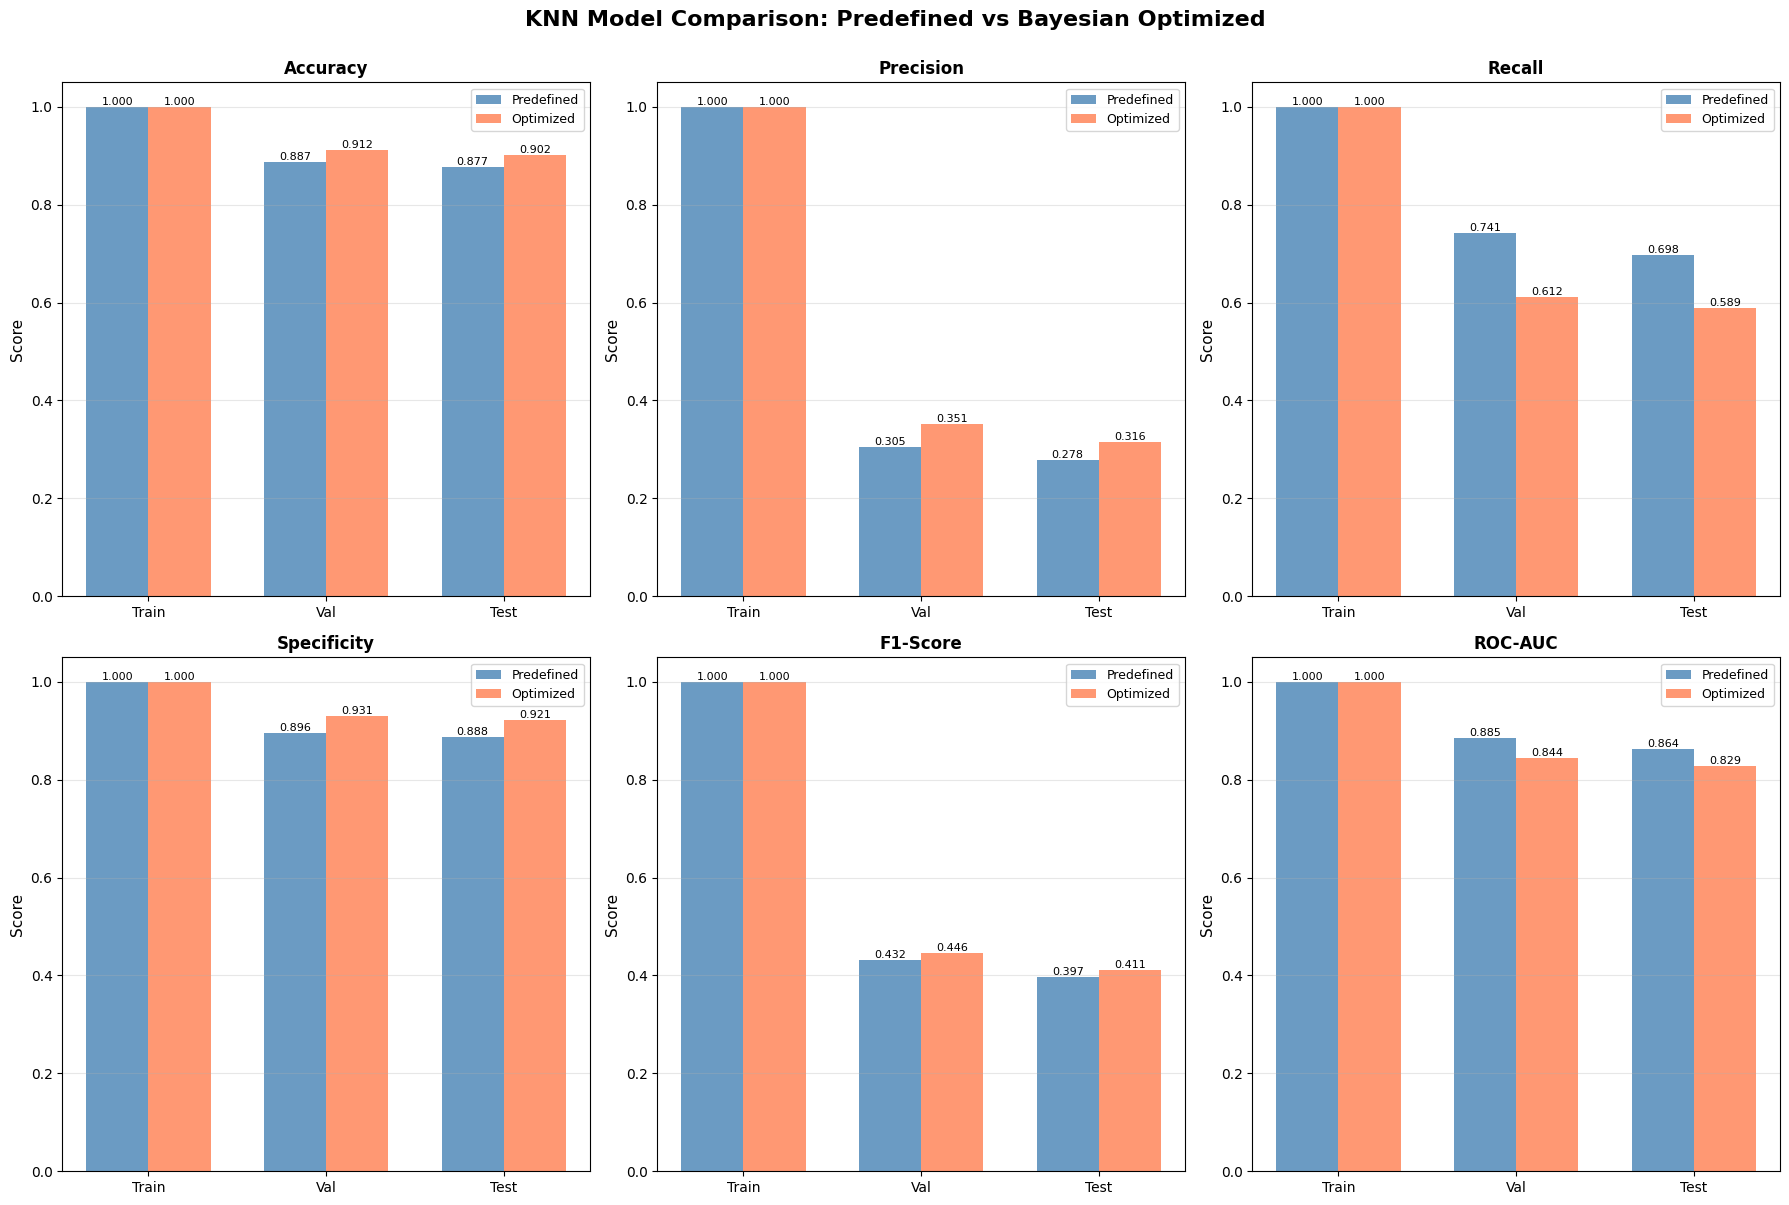

<Figure size 640x480 with 0 Axes>

In [116]:
# Visualize comparison
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# Metric names for display
metric_names = ['Accuracy', 'Precision', 'Recall', 'Specificity', 'F1-Score', 'ROC-AUC']
metric_keys = ['accuracy', 'precision', 'recall', 'specificity', 'f1_score', 'roc_auc']

for idx, (metric_name, metric_key) in enumerate(zip(metric_names, metric_keys)):
    ax = axes[idx // 3, idx % 3]
    
    # Extract values
    predefined = [train_metrics[metric_key], val_metrics[metric_key], test_metrics[metric_key]]
    optimized = [train_metrics_opt[metric_key], val_metrics_opt[metric_key], test_metrics_opt[metric_key]]
    
    x = np.arange(3)
    width = 0.35
    
    # Plot bars
    bars1 = ax.bar(x - width/2, predefined, width, label='Predefined', color='steelblue', alpha=0.8)
    bars2 = ax.bar(x + width/2, optimized, width, label='Optimized', color='coral', alpha=0.8)
    
    # Formatting
    ax.set_ylabel('Score', fontsize=11)
    ax.set_title(metric_name, fontsize=12, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(['Train', 'Val', 'Test'])
    ax.legend(fontsize=9)
    ax.set_ylim([0, 1.05])
    ax.grid(True, alpha=0.3, axis='y')
    
    # Add value labels on bars
    for bars in [bars1, bars2]:
        for bar in bars:
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height,
                   f'{height:.3f}',
                   ha='center', va='bottom', fontsize=8)

plt.suptitle('KNN Model Comparison: Predefined vs Bayesian Optimized', 
             fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

# Save figure
output_dir = Path('../../../../../Rapport_TP/images/KNN')
output_dir.mkdir(parents=True, exist_ok=True)
plt.savefig(output_dir / 'predefined_vs_optimized_comparison_KNN.png', dpi=300, bbox_inches='tight')

### **Save Optimized Model**

In [117]:
# Save the optimized model
model_dir = Path('./models')
model_dir.mkdir(parents=True, exist_ok=True)

model_path = model_dir / 'knn_optimized_model.pkl'
with open(model_path, 'wb') as f:
    pickle.dump(best_knn, f)

print(f"Optimized KNN model saved to: {model_path}")

# Save best parameters
params_path = model_dir / 'knn_best_parameters.pkl'
with open(params_path, 'wb') as f:
    pickle.dump(bayes_search.best_params_, f)

print(f"Best parameters saved to: {params_path}")

# Save metrics comparison
metrics_comparison_path = model_dir / 'knn_metrics_comparison.csv'
comparison_df.to_csv(metrics_comparison_path)

print(f"Metrics comparison saved to: {metrics_comparison_path}")
print("\n" + "="*70)
print("ALL RESULTS SAVED SUCCESSFULLY")
print("="*70)

Optimized KNN model saved to: models\knn_optimized_model.pkl
Best parameters saved to: models\knn_best_parameters.pkl
Metrics comparison saved to: models\knn_metrics_comparison.csv

ALL RESULTS SAVED SUCCESSFULLY
